Name:Rushi Rvairaj Gujarathi ||Roll no-17 ||PRN NO-1252090017

Assingment no:10

10.Assignment on Regression technique.
Download temperature data from the link below.
https://www.kaggle.com/venky73/temperaturesof-india?select=temperatures.csv

This data consists of temperatures of INDIA averaging the temperatures of all places month wise. Temperatures values are recorded in CELSIUS

Apply Linear Regression using a suitable library function and predict the Month-wise temperature.
Assess the performance of regression models using MSE, MAE and R-Square   
metrics
Visualize a simple regression model.

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load Dataset
data = pd.read_csv("temperatures.csv")

print("Dataset Preview:")
print(data.head())

# Take month-wise average temperature
month_temp = data.iloc[:, 1:13].mean()

# Create Month numbers (1-12)
months = np.arange(1, 13).reshape(-1, 1)
temperature = month_temp.values.reshape(-1, 1)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    months, temperature, test_size=0.2, random_state=42)


Dataset Preview:
   YEAR    JAN    FEB    MAR    APR  ...  ANNUAL  JAN-FEB  MAR-MAY  JUN-SEP  OCT-DEC
0  1901  22.40  24.14  29.07  31.91  ...   28.96    23.27    31.46    31.27    27.25
1  1902  24.93  26.58  29.77  31.78  ...   29.22    25.75    31.76    31.09    26.49
2  1903  23.44  25.03  27.83  31.39  ...   28.47    24.24    30.71    30.92    26.26
3  1904  22.50  24.73  28.21  32.02  ...   28.49    23.62    30.95    30.66    26.40
4  1905  22.00  22.83  26.68  30.01  ...   28.30    22.25    30.00    31.33    26.57

[5 rows x 18 columns]


In [ ]:
# Data Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# Performance Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("MSE :", mse)
print("MAE :", mae)
print("R2 Score :", r2)



Model Performance
MSE : 18.93877667970693
MAE : 3.1995321428002974
R2 Score : -2.0405952702708863



Month-wise Predicted Temperatures
Month 1 : 31.01 °C
Month 2 : 30.80 °C
Month 3 : 30.60 °C
Month 4 : 30.40 °C
Month 5 : 30.20 °C
Month 6 : 30.00 °C
Month 7 : 29.80 °C
Month 8 : 29.60 °C
Month 9 : 29.40 °C
Month 10 : 29.20 °C
Month 11 : 29.00 °C
Month 12 : 28.80 °C


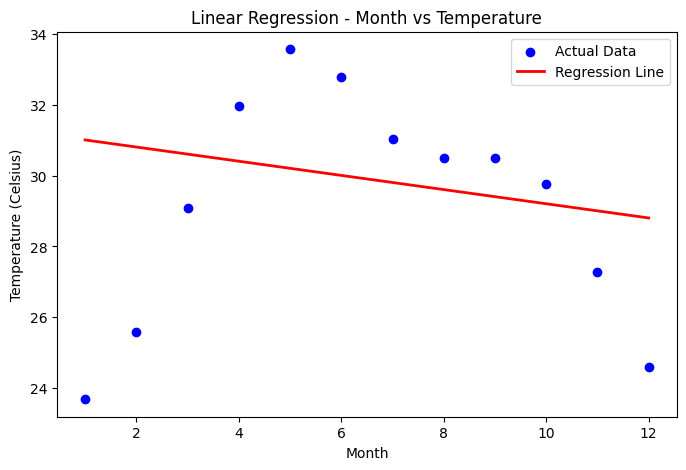

In [ ]:
# Predict all months
months_scaled = scaler.transform(months)
predicted_temp = model.predict(months_scaled)

print("\nMonth-wise Predicted Temperatures")
for i in range(12):
    print(f"Month {i+1} : {predicted_temp[i][0]:.2f} °C")


# Visualization (Scatter + Regression Line)
plt.figure(figsize=(8,5))
plt.scatter(months, temperature, color='blue', label="Actual Data")
plt.plot(months, predicted_temp, color='red', linewidth=2, label="Regression Line")
plt.xlabel("Month")
plt.ylabel("Temperature (Celsius)")
plt.title("Linear Regression - Month vs Temperature")
plt.legend()
plt.show()
